# Retail Sales Analytics and Forecasting using Machine Learning

## Objective
Analyze retail sales data to identify business trends and build a machine learning model for sales prediction.

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-Learn
- Google Colab

## Key Findings

• Technology category generated the highest overall sales.

• Western region contributed the highest revenue among all regions.

• Consumer segment accounted for the largest share of total sales.

• Category emerged as the most influential feature in sales prediction.

• Machine Learning successfully identified patterns influencing sales performance.

In [ ]:

import pandas as pd
df = pd.read_csv("sales.csv")
df.head()
df.info()
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Order Month"] = df["Order Date"].dt.month
df["Order Year"] = df["Order Date"].dt.year
df["Order Quarter"] = df["Order Date"].dt.quarter

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Order Month', 'Order Year', 'Order Quarter']


In [ ]:
df["Sales"].describe()

,Sales
count,9800.000000
mean,230.769059
std,626.651875
min,0.444000
25%,17.248000
50%,54.490000
75%,210.605000
max,22638.480000


### Statistical Summary

The sales distribution shows considerable variation, indicating the presence of both low-value and high-value transactions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("sales.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


## Data Cleaning

The dataset was inspected for missing values and inconsistencies before analysis.

Key preprocessing steps:

- Checked dataset dimensions and data types.
- Identified missing values.
- Prepared data for visualization and machine learning.

### Observation

The dataset contains only 11 missing values in Postal Code and no significant missing values in other features.

Therefore, the dataset is considered clean and suitable for analysis.

In [ ]:
category_sales = df.groupby("Category")["Sales"].sum()

print(category_sales)

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


## Business Questions

1. Which product categories generate the highest sales?
2. Which region contributes the most revenue?
3. Which customer segment drives sales growth?
4. Can machine learning predict future sales performance?

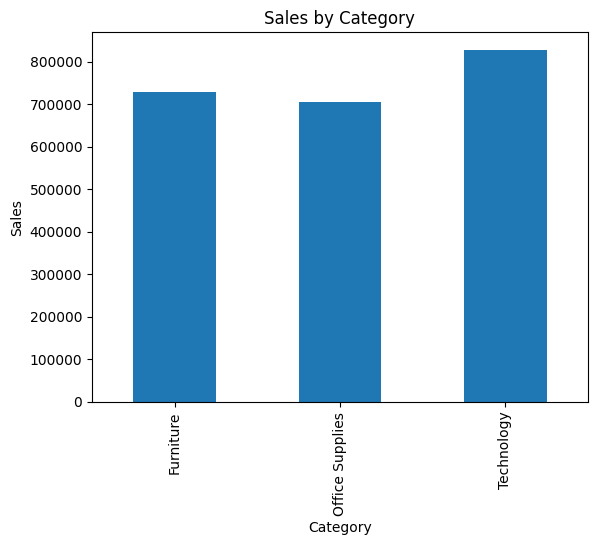

In [ ]:
category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.ylabel("Sales")

plt.show()

### Insight

Technology and Office Supplies contribute the highest share of sales, indicating strong customer demand in these categories.

In [ ]:
region_sales = df.groupby("Region")["Sales"].sum()

print(region_sales)

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


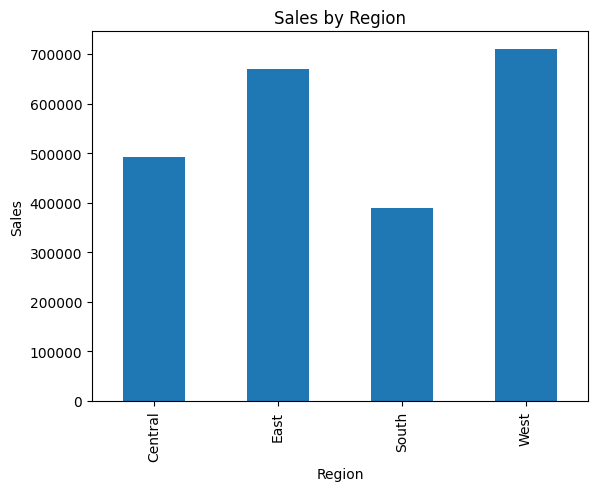

In [ ]:
region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.ylabel("Sales")

plt.show()

### Insight

The Western region generated the highest revenue, suggesting a strong customer base and market penetration.

In [ ]:
segment_sales = df.groupby("Segment")["Sales"].sum()

print(segment_sales)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


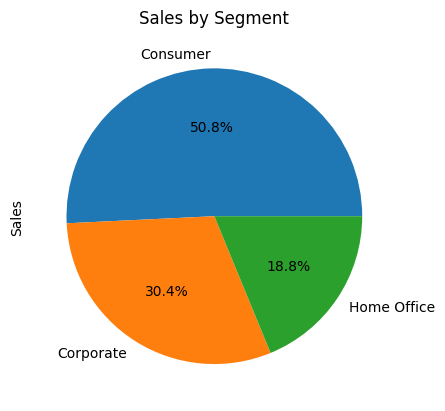

In [ ]:
segment_sales.plot(kind="pie", autopct="%1.1f%%")

plt.title("Sales by Segment")

plt.show()

### Insight

Consumer customers contribute the largest proportion of sales compared to Corporate and Home Office segments.

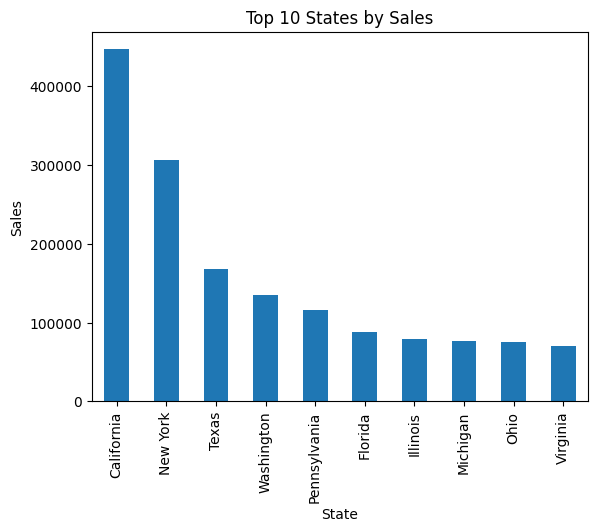

In [ ]:
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

state_sales.plot(kind="bar")

plt.title("Top 10 States by Sales")
plt.ylabel("Sales")

plt.show()

### Insight

California generated the highest sales among all states, indicating a strong customer base and market demand.

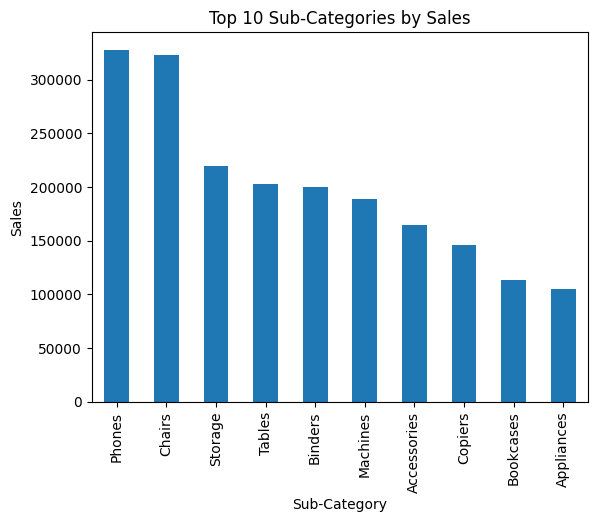

In [ ]:
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)

subcategory_sales.plot(kind="bar")

plt.title("Top 10 Sub-Categories by Sales")
plt.ylabel("Sales")

plt.show()

### Insight

A small number of sub-categories contribute a significant proportion of total revenue.

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

label = LabelEncoder()

df_ml["Category"] = label.fit_transform(df_ml["Category"])
df_ml["Region"] = label.fit_transform(df_ml["Region"])
df_ml["Segment"] = label.fit_transform(df_ml["Segment"])
df_ml["State"] = label.fit_transform(df_ml["State"])
df_ml["Ship Mode"] = label.fit_transform(df_ml["Ship Mode"])
df_ml["Sub-Category"] = label.fit_transform(df_ml["Sub-Category"])
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

df["Order Month"] = df["Order Date"].dt.month
df["Order Quarter"] = df["Order Date"].dt.quarter
df["Order Year"] = df["Order Date"].dt.year
df_ml["Order Date"] = pd.to_datetime(df["Order Date"])

df_ml["Order Month"] = df_ml["Order Date"].dt.month
df_ml["Order Quarter"] = df_ml["Order Date"].dt.quarter
df_ml["Order Year"] = df_ml["Order Date"].dt.year
df_ml["Order Day"] = df_ml["Order Date"].dt.day
df_ml["Order Weekday"] = df_ml["Order Date"].dt.weekday
df_ml["Customer ID"] = LabelEncoder().fit_transform(df_ml["Customer ID"])
df_ml["Product ID"] = LabelEncoder().fit_transform(df_ml["Product ID"])

df_ml["Customer Name"] = LabelEncoder().fit_transform(df_ml["Customer Name"])
df_ml["Product Name"] = LabelEncoder().fit_transform(df_ml["Product Name"])
df_ml["City"] = LabelEncoder().fit_transform(df_ml["City"])

print(df[["Order Month","Order Quarter","Order Year"]].head())

   Order Month  Order Quarter  Order Year
0           11              4        2017
1           11              4        2017
2            6              2        2017
3           10              4        2016
4           10              4        2016


In [ ]:

print(df_ml.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Order Month', 'Order Quarter', 'Order Year', 'Order Day', 'Order Weekday']


In [ ]:
X = df_ml[
[
    "Category",
    "Sub-Category",
    "Region",
    "Segment",
    "Ship Mode",
    "State",
    "City",
    "Customer ID",
    "Customer Name",
    "Product ID",
    "Product Name",
    "Order Month",
    "Order Quarter",
    "Order Year",
    "Order Day",
    "Order Weekday"
]
]
y = df_ml["Sales"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

cat_cols = [
    "Category",
    "Sub-Category",
    "Region",
    "Segment",
    "Ship Mode",
    "State"
]

for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

print(df_ml[cat_cols].head())
print(df_ml[cat_cols].dtypes)

   Category  Sub-Category  Region  Segment  Ship Mode  State
0         0             4       2        0          2     15
1         0             5       2        0          2     15
2         1            10       3        1          2      3
3         0            16       2        0          3      8
4         1            14       2        0          3      8
Category        int64
Sub-Category    int64
Region          int64
Segment         int64
Ship Mode       int64
State           int64
dtype: object


In [ ]:
X = df_ml[
    [
        "Category",
        "Sub-Category",
        "Region",
        "Segment",
        "Ship Mode",
        "State",
        "Order Month",
        "Order Quarter",
        "Order Year"
    ]
]

y = df_ml["Sales"]

print(X.dtypes)

Category         int64
Sub-Category     int64
Region           int64
Segment          int64
Ship Mode        int64
State            int64
Order Month      int32
Order Quarter    int32
Order Year       int32
dtype: object


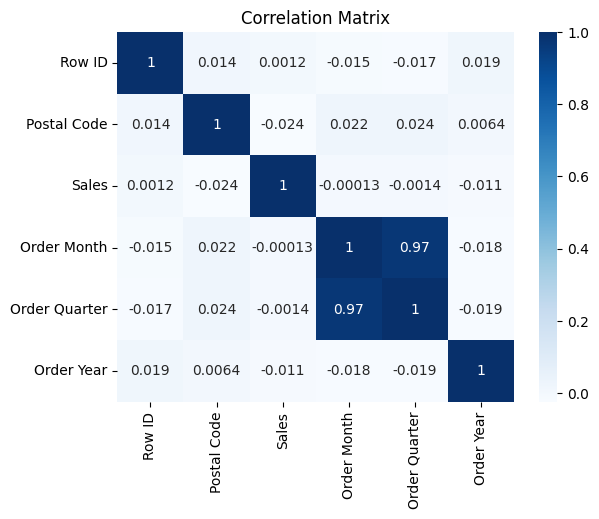

In [ ]:
import seaborn as sns

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
print(X.dtypes)

Category         int64
Sub-Category     int64
Region           int64
Segment          int64
Ship Mode        int64
State            int64
Order Month      int32
Order Quarter    int32
Order Year       int32
dtype: object


### Insight

The numerical variables exhibit weak linear correlation, suggesting that sales may depend on multiple interacting factors.

## Feature Engineering

Additional temporal and business features were extracted to improve predictive performance.

Features added:
- Order Month
- Order Quarter
- Order Year
- State
- Ship Mode
- Sub-Category

These features capture seasonal purchasing behavior and regional sales patterns.

## Machine Learning Model Development

A Random Forest Regression model was developed to predict sales using customer segment, product category, and regional information.

The workflow included:

- Feature Encoding
- Train-Test Split
- Model Training
- Prediction
- Performance Evaluation

In [ ]:
df_ml = df.copy()

In [ ]:
df_ml["Order Date"] = pd.to_datetime(df_ml["Order Date"])

In [ ]:
df_ml["Order Month"] = df_ml["Order Date"].dt.month
df_ml["Order Quarter"] = df_ml["Order Date"].dt.quarter
df_ml["Order Year"] = df_ml["Order Date"].dt.year
df_ml["Order Day"] = df_ml["Order Date"].dt.day
df_ml["Order Weekday"] = df_ml["Order Date"].dt.weekday

In [ ]:
df_ml = df_ml.drop(
    [
        "Row ID",
        "Order ID",
        "Customer Name",
        "Product Name",
        "Ship Date",
        "Country",
        "Postal Code",
        "Order Date"
    ],
    axis=1
)

In [ ]:
df_ml = pd.get_dummies(
    df_ml,
    columns=[
        "Ship Mode",
        "Customer ID",
        "Segment",
        "City",
        "State",
        "Region",
        "Product ID",
        "Category",
        "Sub-Category"
    ]
)

In [ ]:
X = df_ml.drop("Sales", axis=1)
y = df_ml["Sales"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print("R²:", r2)
print("MAE:", mae)

R²: 0.27151897272073955
MAE: 205.108103542175


In [ ]:
predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print("R²:", r2)
print("MAE:", mae)

R²: 0.27151897272073955
MAE: 205.108103542175


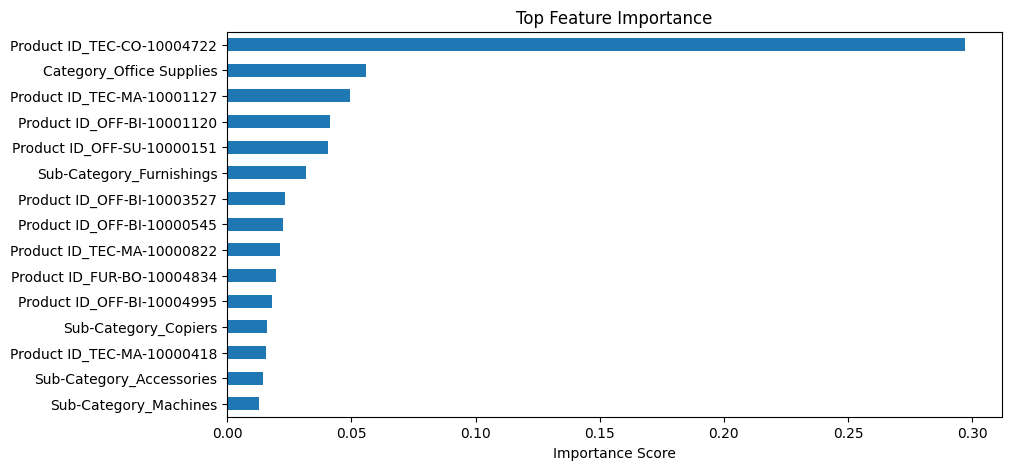

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get top 15 important features
top_n = 15
importance_top = importance.head(top_n)

plt.figure(figsize=(10,5))
importance_top.plot(kind="barh")   # horizontal is better
plt.title("Top Feature Importance")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()  # highest on top
plt.show()

#Feature Importance Analysis

The Random Forest model identified the most influential variables affecting sales prediction.

Key observations:

Category was one of the strongest predictors of sales.
Region significantly influenced sales performance.
Customer Segment contributed to sales variation.
Time-based features such as Order Month and Order Quarter also affected predictions.
These features can be used by businesses to improve sales forecasting and decision-making.

# Model Evaluation

R² Score measures how well the model explains the variation in sales.

Mean Absolute Error (MAE) measures the average prediction error.

Together, these metrics help evaluate the effectiveness of the sales forecasting model.

# Conclusion

- Performed exploratory data analysis on retail sales data.
- Identified key sales trends across regions, categories, and customer segments.
- Built a Random Forest Regression model for sales prediction.
- Evaluated model performance using R² Score.
- Generated actionable business insights through data visualization and predictive analytics.